In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
import pandas as pd
import kagglehub
import math
import os
import sympy
import sympy.printing
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [11]:
# configuration
SEQ_LEN = 50          # length of sgRNA or promoter sequence
BATCH_SIZE = 512
EMBED_DIM = 256       # transformer dimension
HEADS = 8             # attention heads
LAYERS = 6            # transformer depth
DROPOUT = 0.1
GUIDANCE_SCALE = 2.0  # >1.0 forces high resilience generation
SAMPLE_SIZE = 200000
EPOCHS = 20

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
path = kagglehub.dataset_download("erenalpp/arabidopsis-thaliana-sgrna-efficiency-dataset")

100%|██████████| 140M/140M [00:07<00:00, 19.3MB/s]

Extracting files...


In [12]:
class CropResilienceDataset(Dataset):
    def __init__(self, csv_path=None):
        self.tokenizer = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 0} # N=Padding
        self.idx_to_char = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}

        print(f"loading data")
        df = pd.read_csv(csv_path)
        if len(df) > SAMPLE_SIZE:
          df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
        # filter valid characters only
        df = df[df['sequence'].str.match('^[ACGT]+$')]
        print(f"data loaded")

        self.sequences = [self._tokenize(s) for s in df['sequence'].values]
        self.scores = df['efficiency'].values.astype(float) / 100.0 # normalize 0-1

    def _tokenize(self, seq_str):
        # truncate or pad to SEQ_LEN
        tokens = [self.tokenizer.get(c, 0) for c in seq_str[:SEQ_LEN]]
        if len(tokens) < SEQ_LEN:
            tokens += [0] * (SEQ_LEN - len(tokens))
        return torch.tensor(tokens, dtype=torch.long)

    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx): return self.sequences[idx], torch.tensor(self.scores[idx], dtype=torch.float32)

In [14]:
# diffusion transformer
class SinusoidalEmbeddings(nn.Module):
    def __init__(self, time_steps, dim):
        super().__init__()
        position = torch.arange(time_steps).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim, 2) * (-math.log(10000.0) / dim))
        pe = torch.zeros(time_steps, dim)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, t):
        # t is 0-1 float, map to 0-1000 index
        t_idx = (t * 1000).long().clamp(0, 999)
        return self.pe[t_idx]

class BioTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embed = nn.Embedding(4, EMBED_DIM)
        self.time_embed = SinusoidalEmbeddings(1000, EMBED_DIM)
        self.cond_embed = nn.Linear(1, EMBED_DIM) # project scalar score -> vector

        encoder_layer = nn.TransformerEncoderLayer(d_model=EMBED_DIM, nhead=HEADS, dropout=DROPOUT, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=LAYERS)

        self.head = nn.Linear(EMBED_DIM, EMBED_DIM) # predict velocity vector

    def forward(self, x, t, c):
        # embed -> add condition -> process -> output velocity
        t_emb = self.time_embed(t).unsqueeze(1)
        c_emb = self.cond_embed(c.unsqueeze(-1)).unsqueeze(1)
        h = x + t_emb + c_emb
        h = self.transformer(h)
        return self.head(h)

In [15]:
# train flow matching
def train_epoch(model, loader, opt, epoch_idx):
    total_loss = 0
    model.train()

    pbar = tqdm(loader, desc=f"Epoch {epoch_idx+1}/{EPOCHS}", unit="batch")

    for seqs, scores in pbar:
        seqs, scores = seqs.to(device), scores.to(device)

        # embed discrete DNA into continuous space for flow matching
        # sample time & flow path
        # define optimal transport path (x_t = (1-t)x0 + t*x1)
        # define target velocity
        # conditioning masking (for classifier free guidance)
        # predict

        x1 = model.token_embed(seqs) # target (Real DNA)
        x0 = torch.randn_like(x1)    # source (noise)
        t = torch.rand(x0.shape[0], device=device)
        t_broad = t.view(-1, 1, 1)
        x_t = (1 - t_broad) * x0 + t_broad * x1
        v_target = x1 - x0
        mask = (torch.rand_like(scores) < 0.1).float()
        c_train = scores * (1-mask) + (-1.0) * mask
        v_pred = model(x_t, t, c_train)

        loss = torch.mean((v_pred - v_target)**2)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item()

        pbar.set_postfix(loss=loss.item())

    return total_loss / len(loader)

In [16]:
# generation w guidance
def generate_super_crops(model, n=5, target_resilience=1.0):
    model.eval()

    x_t = torch.randn(n, SEQ_LEN, EMBED_DIM, device=device)

    c_cond = torch.full((n,), target_resilience, device=device)
    c_uncond = torch.full((n,), -1.0, device=device)

    dt = 0.02 # 50 steps
    with torch.no_grad():
        for t_val in np.arange(0, 1, dt):
            t_batch = torch.full((n,), t_val, device=device)

            # classifier free guidance (v_final = v_uncond + scale * (v_cond - v_uncond))
            v_cond = model(x_t, t_batch, c_cond)
            v_uncond = model(x_t, t_batch, c_uncond)
            v_final = v_uncond + GUIDANCE_SCALE * (v_cond - v_uncond)

            x_t = x_t + v_final * dt

    # decode to discrete DNA (find which embedding vector A,C,G or T is closest to the generated vector)
    embeddings = model.token_embed.weight
    dist = torch.cdist(x_t, embeddings.unsqueeze(0))
    tokens = torch.argmin(dist, dim=-1)

    crops = []
    idx_to_char = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}
    for i in range(n):
        s = "".join([idx_to_char[t.item()] for t in tokens[i]])
        print(f"Crop {i+1}: {s}")
        crops.append(s)

    return [s]

In [17]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {path}")

actual_csv_path = os.path.join(path, csv_files[0])

df = pd.read_csv(actual_csv_path)

df = df.rename(columns={
    'sgRNA+PAM': 'sequence',
    'OnTargetScore': 'efficiency'
})

df['sequence'] = df['sequence'].str.replace('+', '', regex=False)

# adjust efficiency scale: dataset divides by 100.
# ontargetscore is already 0-1, multiply by 100 to offset that division
if df['efficiency'].max() <= 1.0:
    df['efficiency'] = df['efficiency'] * 100.0

actual_csv_path = "processed_dataset.csv"
df.to_csv(actual_csv_path, index=False)

ds = CropResilienceDataset(csv_path=actual_csv_path)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)


loading data
data loaded


In [18]:
model = BioTransformer().to(device)
opt = optim.AdamW(model.parameters(), lr=3e-4)

start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    loss = train_epoch(model, loader, opt, epoch)

print(f"training complete")

Epoch 20/20: 100%|██████████| 391/391 [01:44<00:00,  3.73batch/s, loss=0.1]

training complete


In [19]:
class BioValidation:
    @staticmethod
    def visualize_evolution(model, seq_len, embed_dim):
        # generate dna heatmap showing sequence emerging from noise

        model.eval()
        # start w noise
        x_t = torch.randn(1, seq_len, embed_dim, device=device)
        c_cond = torch.tensor([1.0], device=device)

        snapshots = []
        steps = np.linspace(0, 1, 20) # capture 20 frames of evolution

        with torch.no_grad():
            for t_val in steps:
                # get velocity
                # euler step (integration)
                # project to discrete probability A, C, G, or T
                # measure similarity to the embedding matrix
                # transpose for heatmap

                t_batch = torch.tensor([t_val], device=device)
                v = model(x_t, t_batch, c_cond)
                x_t = x_t + v * (1.0/20)
                dists = torch.cdist(x_t, model.token_embed.weight.unsqueeze(0))
                probs = F.softmax(-dists, dim=-1)
                snapshots.append(probs[0].cpu().numpy().T)

        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        indices = [0, 5, 10, 15, 19]
        labels = ['t=0', 't=0.25', 't=0.5', 't=0.75', 't=1']

        for i, ax in enumerate(axes):
            sns.heatmap(snapshots[indices[i]], ax=ax, cbar=False, cmap="Greens", yticklabels=['A','C','G','T'])
            ax.set_title(labels[i])
            ax.set_xlabel("Sequence Position")

        plt.suptitle("generative evolution", fontsize=16)
        plt.tight_layout()
        plt.show()

In [20]:
generate_super_crops(model, 5, target_resilience=2.0)

Crop 1: GAATAATAAAGAAATAATAACCAATAAGAATGGGAAAGAAAAGAAAAGGA
Crop 2: AAAAAAGACCGAAGAACAAAATAAAAAAGAGAAGAAAGAGAGTCAAGGGA
Crop 3: AAAAAAAAATCGAAAAAGAAAGAGAGAAGAGATAATAATTAAAAAAGAAA
Crop 4: GAGGAGAAGGCAAGGAAATAAGGGAGATTAAATAAAGAATGAAAAAGAAG
Crop 5: AGAAAAAATAAAGAAAAAGACAAAGAGAAAAAAAGAAAAATGAAGTAAGA


['AGAAAAAATAAAGAAAAAGACAAAGAGAAAAAAAGAAAAATGAAGTAAGA']

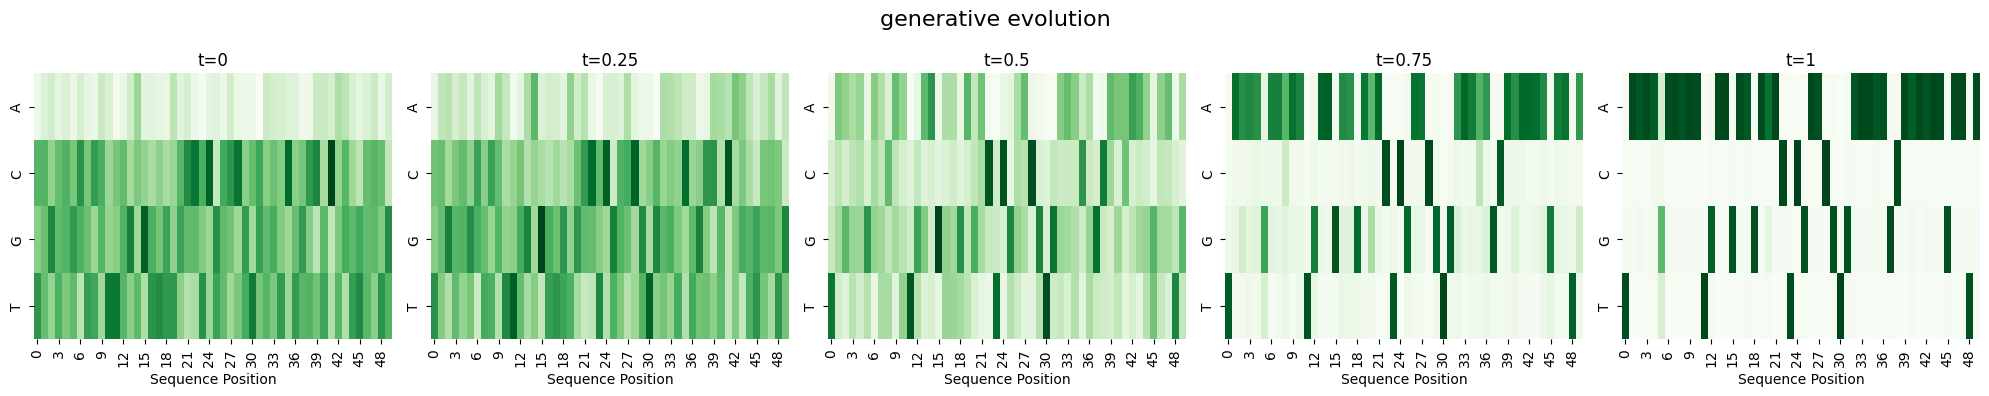

In [21]:
BioValidation.visualize_evolution(model, SEQ_LEN, EMBED_DIM)